# Training and testing
Emanuel de Jong (495804) - Erik Markvoort (519894)

## Imports

In [1]:
import os
import pickle
from IPython.display import display, Markdown

import matplotlib.pyplot as plt
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

## Load input

In [2]:
with open(f'..{os.sep}dataset-numpy{os.sep}features_after_analysis.pkl', 'rb') as f:
    features = pickle.load(f)

## Global

In [3]:
label_columns = ['label', 'label_num']

# labels ordered by label_num
labels = features.drop_duplicates(subset='label_num').sort_values(by='label_num')['label'].tolist()

## Split data

In [4]:
test_size = 0.2

# Use the same amount of images for each label (balancing)
smallest_label_data_count = features['label_num'].value_counts().min()
balanced_features = features.groupby('label_num')[features.columns.tolist()].apply(lambda x: x.sample(smallest_label_data_count))

X = balanced_features.drop(columns=label_columns)
y = balanced_features['label_num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=0)

train_distribution = y_train.value_counts()
print(train_distribution)

label_num
9     61
1     61
6     61
8     61
7     61
2     61
10    61
4     61
0     60
5     60
3     60
Name: count, dtype: int64


## Train

In [5]:
pipeline = Pipeline([
    ('classifier', 'placeholder')
])

params = []
def add_params(model_params):
    processed_model_params = {}
    for key, value in model_params.items():
        if key == 'classifier':
            processed_model_params[key] = [value]
        else:
            processed_model_params[f'classifier__{key}'] = value
    
    params.append(processed_model_params)

The params used are the ones that were previously found as the best. The commented params are the tested values. This is done to make the code run faster from now on.

#### SVM

In [6]:
add_params({
    'classifier': SVC(),

#     'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
#     'degree': list(range(1, 6)),
#     'gamma': ['scale', 'auto'],
#     'coef0': [0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
#     'shrinking': [True, False],
#     'probability': [True, False],
#     'tol': [0.001, 0.002, 0.004, 0.006, 0.008, 0.01],
#     'break_ties': [True, False],

    'kernel': ['poly'],
    'degree': [5],
    'gamma': ['scale'],
    'coef0': [1.0],
    'shrinking': [True],
    'probability': [True],
    'tol': [0.001],
    'break_ties': [True],
    })

#### KNN

In [7]:
add_params({
    'classifier': KNeighborsClassifier(),
    
#     'n_neighbors': [2, 4, 6, 8, 10, 12],
#     'weights': ['uniform', 'distance'],
#     'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
#     'leaf_size': [10, 20, 30, 40],
#     'p': [1.0, 2.0, 3.0]

    'n_neighbors': [4],
    'weights': ['distance'],
    'algorithm': ['auto'],
    'leaf_size': [10],
    'p': [1.0]
    })

#### decision tree

In [8]:
add_params({
    'classifier': DecisionTreeClassifier(random_state=0),

#     'criterion': ['entropy', 'gini', 'log_loss'],
#     'splitter': ['best', 'random'],
#     'min_samples_split': [1, 2, 3, 4],
#     'min_samples_leaf': [1, 2, 3, 4],
#     'max_leaf_nodes': [None, 4, 2],
#     'min_impurity_decrease': [0.0, 0,1, 0,2],
#     'class_weight': ['balanced', None]

    'criterion': ['entropy'],
    'splitter': ['best'],
    'min_samples_split': [2],
    'min_samples_leaf': [2],
    'max_leaf_nodes': [None],
    'min_impurity_decrease': [0.0],
    'class_weight': [None]
    })

#### Naive bayes

In [9]:
add_params({
    'classifier': GaussianNB(),

#     'var_smoothing': [1e-9, 2e-9, 3e-9, 4e-9, 5e-9, 9e-9, 5e-10, 6e-10, 7e-10, 8e-10, 9e-10],

    'var_smoothing': [9e-9],
    })

#### Random Forest

In [10]:
add_params({
    'classifier': RandomForestClassifier(random_state=0),

#     'n_estimators': [50, 100, 150],
#     'criterion': ['entropy', 'gini', 'log_loss'],
#     'min_samples_split': [1, 2, 3, 4],
#     'min_samples_leaf': [1, 2, 3, 4],
#     'max_leaf_nodes': [None, 4, 2],
#     'min_impurity_decrease': [0.0, 0,1, 0,2],
#     'class_weight': ['balanced', 'balanced_subsample', None]

    'n_estimators': [50],
    'criterion': ['entropy'],
    'min_samples_split': [3],
    'min_samples_leaf': [1],
    'max_leaf_nodes': [None],
    'min_impurity_decrease': [0.0],
    'class_weight': [None]
    })

#### Logistic regression

Logistic regression is similar to linear regression, in which the function used to make a prediction model is a logistic function(log(x))

In [11]:
add_params({
    'classifier': LogisticRegression(random_state=0),

#     'penalty': ['l1', 'l2', 'elasticnet'],
#     'dual': [True, False],
#     'C': [0.5, 1.0, 1.5],
#     'fit_intercept': [True, False],
#     'intercept_scaling': [0.5, 1.0, 1.5],
#     'class_weight': ['balanced', None],
#     'warm_start': [True, False]

    'penalty': ['l2'],
    'dual': [False],
    'C': [1.5],
    'fit_intercept': [True],
    'intercept_scaling': [1.5],
    'class_weight': ['balanced'],
    'warm_start': [True]
    })

#### Extra Trees

The extra trees algorithm works much like the random forest algorithm, but instead, creates new sampling for each new tree. The sampling is taking a set of data on which it bases the decision making in the tree.

In [12]:
add_params({
    'classifier': ExtraTreesClassifier(random_state=0),

#     'n_estimators': [50, 100, 150],
#     'criterion': ['entropy', 'gini', 'log_loss'],
#     'min_samples_split': [1, 2, 3, 4],
#     'min_samples_leaf': [1, 2, 3, 4],
#     'max_leaf_nodes': [None, 4, 2],
#     'min_impurity_decrease': [0.0, 0,1, 0,2],
#     'class_weight': ['balanced', 'balanced_subsample', None],

    'n_estimators': [50],
    'criterion': ['gini'],
    'min_samples_split': [2],
    'min_samples_leaf': [1],
    'max_leaf_nodes': [None],
    'min_impurity_decrease': [0.0],
    'class_weight': ['balanced'],
    })

## Get best model
The grid search trains all different models per param combination with KFold. The best_model is the model with the highest score of them all.

In [13]:
folds = 5
scoring = 'accuracy'

grid_search = GridSearchCV(pipeline, params, cv=folds, scoring=scoring)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

## Save best model

In [14]:
joblib.dump(best_model, f'..{os.sep}dataset-numpy{os.sep}best_model.joblib')
joblib.dump(best_model, f'..{os.sep}webserver{os.sep}models{os.sep}best_model.joblib')

['..\\webserver\\models\\best_model.joblib']

## Conclusion
Here we show the classification report and the confusion matrix of the model with the highest accuracy.

Best model: SVC(break_ties=True, coef0=1.0, degree=5, kernel='poly', probability=True)

              precision    recall  f1-score   support

         Ing       0.88      0.94      0.91        16
         Tyr       0.80      0.80      0.80        15
       earth       0.71      0.80      0.75        15
   elk-sedge       0.83      0.62      0.71        16
        game       0.87      0.87      0.87        15
        hail       0.88      0.88      0.88        16
         ice       1.00      0.93      0.97        15
         joy       0.88      0.93      0.90        15
        lake       0.80      0.80      0.80        15
      wealth       0.75      0.80      0.77        15
        year       0.93      0.93      0.93        15

    accuracy                           0.85       168
   macro avg       0.85      0.85      0.84       168
weighted avg       0.85      0.85      0.84       168



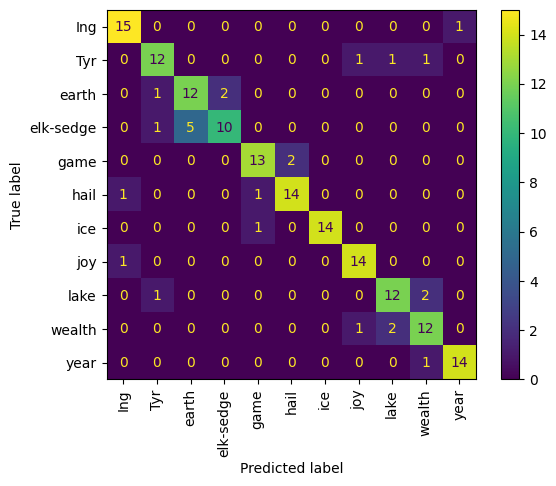

In [15]:
best_model = joblib.load(f'..{os.sep}dataset-numpy{os.sep}best_model.joblib')

print(f'Best model: {best_model.named_steps["classifier"]}\n')

y_pred = best_model.predict(X_test)

report = classification_report(y_test, y_pred, target_names = labels)
print(report)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels = labels)
disp.plot()

plt.xticks(rotation=90)
plt.show()